# 🌞 TOGO: Solar Data Profiling, Cleaning & EDA

**Branch:** `eda-sieraleon`  
**Objective:** Profile, clean, and explore Benin's solar dataset end-to-end so it's ready for cross-country comparison and region-ranking tasks.

In [1]:
#import warnings
#warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats
from pathlib import Path

# Optional: windrose for wind analysis
try:
    from windrose import WindroseAxes
    HAS_WINDROSE = True
except ImportError:
    HAS_WINDROSE = False
    print('windrose not installed — radial bar fallback will be used. pip install windrose')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

COUNTRY = 'Togo'
DATA_DIR = Path('E:/project 2026/Cross-Country-Solar-Farm-Analysis/data')
DATA_DIR.mkdir(exist_ok=True)

print('Libraries loaded ✔')


Libraries loaded ✔


# 1. load data 

In [2]:
# ── Load raw CSV ────────────────────────────────────────────────

RAW_PATH = DATA_DIR / 'togo.csv'   # <── change if needed

if RAW_PATH.exists():
    df = pd.read_csv(RAW_PATH, parse_dates=['Timestamp'])
else:
    raise FileNotFoundError(f"Raw data file not found at {RAW_PATH}. Please check the path and filename.")
print(f"Data loaded from {RAW_PATH} with shape {df.shape}")
df.head()

Data loaded from E:\project 2026\Cross-Country-Solar-Farm-Analysis\data\togo.csv with shape (525600, 19)


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-25 00:01:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
1,2021-10-25 00:02:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2,2021-10-25 00:03:00,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
3,2021-10-25 00:04:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
4,2021-10-25 00:05:00,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


##  2.Raw data distribution overvier  Before preprocessing 

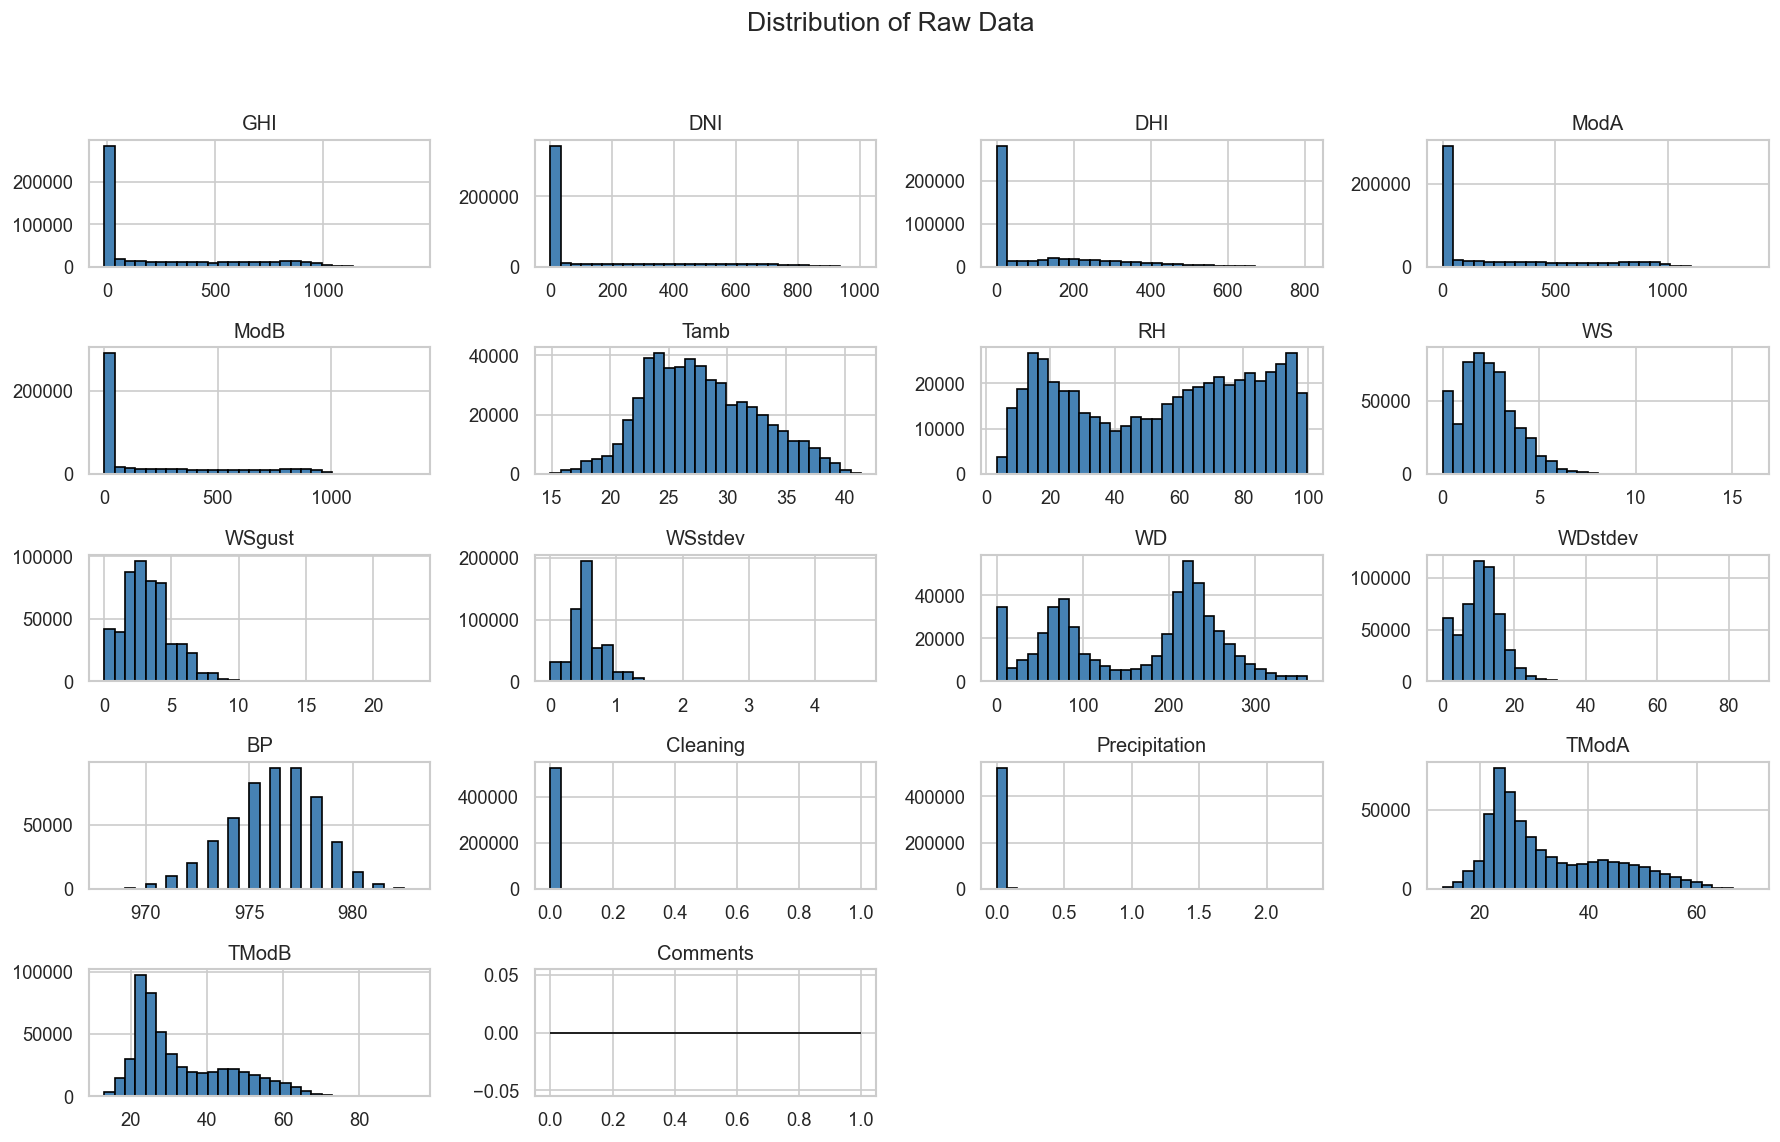

In [3]:
# data distribution and quality checks
# visualising of raw data
#to check wether the data is normally distributed or not
#exclude timestamp from the list of columns for histogram plotting
numeric_cols = df.select_dtypes(include=[np.number]).columns
histograms = df[numeric_cols].hist(bins=30, figsize=(15, 10), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Raw Data', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 3.  Summary Statistics & Missing-Value Report

In [4]:
# ── 2.1  Descriptive statistics ─────────────────────────────────
print('=== df.describe() — all numeric columns ===')
df.describe().round(2)

=== df.describe() — all numeric columns ===


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,525600.00,0.0
mean,2022-04-25 12:00:30,230.56,151.26,116.44,226.14,219.57,27.75,55.01,2.37,3.23,0.56,161.74,10.56,975.92,0.00,0.00,32.44,33.54,NaN
min,2021-10-25 00:01:00,-12.70,0.00,0.00,0.00,0.00,14.90,3.30,0.00,0.00,0.00,0.00,0.00,968.00,0.00,0.00,13.10,13.10,NaN
25%,2022-01-24 06:00:45,-2.20,0.00,0.00,0.00,0.00,24.20,26.50,1.40,1.90,0.40,74.80,6.90,975.00,0.00,0.00,23.90,23.60,NaN
50%,2022-04-25 12:00:30,2.10,0.00,2.50,4.40,4.30,27.20,59.30,2.20,2.90,0.50,199.10,10.80,976.00,0.00,0.00,28.40,28.40,NaN
75%,2022-07-25 18:00:15,442.40,246.40,215.70,422.52,411.00,31.10,80.80,3.20,4.40,0.70,233.50,14.10,977.00,0.00,0.00,40.60,43.00,NaN
max,2022-10-25 00:00:00,1424.00,1004.50,805.70,1380.00,1367.00,41.40,99.80,16.10,23.10,4.70,360.00,86.90,983.00,1.00,2.30,70.40,94.60,NaN
std,NaN,322.53,250.96,156.52,317.35,307.93,4.76,28.78,1.46,1.88,0.27,91.88,5.92,2.15,0.02,0.03,11.00,12.77,NaN


In [5]:
print(df.isna().sum())
print (f"Missing values: {df.isna().sum().sum()} total, {df.isna().mean().mean():.2%} overall")

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64
Missing values: 525600 total, 5.26% overall


In [6]:
# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Timestamp      525600 non-null  datetime64[us]
 1   GHI            525600 non-null  float64       
 2   DNI            525600 non-null  float64       
 3   DHI            525600 non-null  float64       
 4   ModA           525600 non-null  float64       
 5   ModB           525600 non-null  float64       
 6   Tamb           525600 non-null  float64       
 7   RH             525600 non-null  float64       
 8   WS             525600 non-null  float64       
 9   WSgust         525600 non-null  float64       
 10  WSstdev        525600 non-null  float64       
 11  WD             525600 non-null  float64       
 12  WDstdev        525600 non-null  float64       
 13  BP             525600 non-null  int64         
 14  Cleaning       525600 non-null  int64         
 15  Precipitati

## 3 Outlier Detection & Basic Cleaning  for Solar data of Benin
* There are negative values in the data for column of GHI, DNI and DHI  which is impossible in real 
* So that we must set to zeo 

In [7]:
# ── 3.1  Negative irradiance (physically impossible at night → set 0) ──
for col in ['GHI', 'DNI', 'DHI']:
    if col in df.columns:
        n_neg = (df[col] < 0).sum()
        df[col] = df[col].clip(lower=0)
        print(f'  {col}: clipped {n_neg} negative values → 0')

# Fix obvious sensor errors (e.g. WS = -9999)
for col in ['WS', 'WSgust']:
    if col in df.columns:
        bad = (df[col] < 0).sum()
        df.loc[df[col] < 0, col] = np.nan
        print(f'  {col}: set {bad} impossible negatives → NaN')

  GHI: clipped 257385 negative values → 0
  DNI: clipped 0 negative values → 0
  DHI: clipped 0 negative values → 0
  WS: set 0 impossible negatives → NaN
  WSgust: set 0 impossible negatives → NaN


# Z-score outlier flagging

In [8]:
 #── 3.2  Z-score outlier flagging ───────────────────────────────
ZSCORE_COLS = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
ZSCORE_COLS = [c for c in ZSCORE_COLS if c in df.columns]

z_scores = df[ZSCORE_COLS].apply(lambda s: np.abs(stats.zscore(s, nan_policy='omit')))
df['outlier_flag'] = (z_scores > 3).any(axis=1)

outlier_summary = pd.DataFrame({
    'outlier_rows': (z_scores > 3).sum(),
    'outlier_pct':  ((z_scores > 3).sum() / len(df) * 100).round(2)
})

print(f'Total rows flagged as outliers (|Z|>3 in any column): {df["outlier_flag"].sum()} '
      f'({df["outlier_flag"].mean()*100:.2f}%)')
display(outlier_summary)

Total rows flagged as outliers (|Z|>3 in any column): 9257 (1.76%)


,outlier_rows,outlier_pct
GHI,314,0.06
DNI,1062,0.20
DHI,3415,0.65
ModA,137,0.03
ModB,206,0.04
WS,3510,0.67
WSgust,3915,0.74


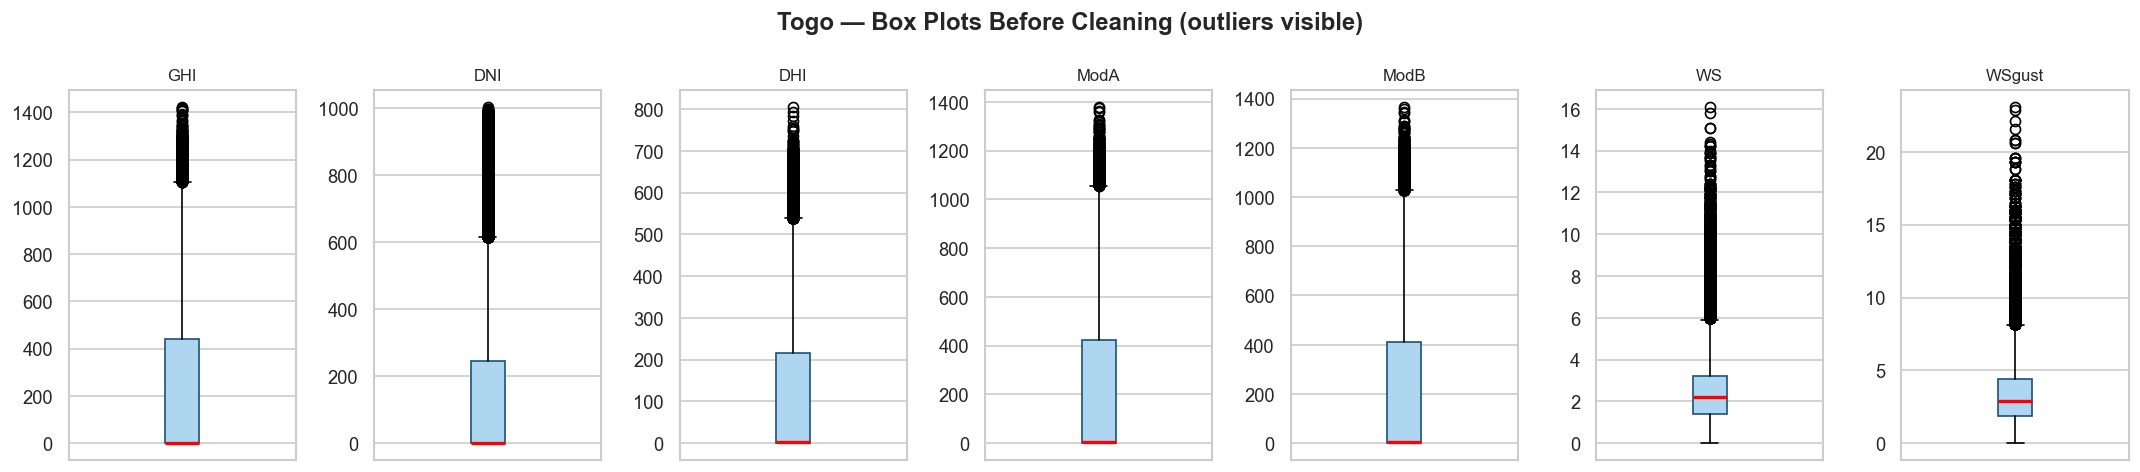

In [9]:
# ── 3.3  Visualise outliers — box plots ─────────────────────────
fig, axes = plt.subplots(1, len(ZSCORE_COLS), figsize=(18, 4))
for ax, col in zip(axes, ZSCORE_COLS):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#AED6F1', color='#1A5276'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=10)
    ax.set_xticks([])
fig.suptitle(f'{COUNTRY.title()} — Box Plots Before Cleaning (outliers visible)', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ── 3.4  Impute nulls (median) in key columns ────────────────────
KEY_COLS = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust', 'Tamb', 'RH']
KEY_COLS = [c for c in KEY_COLS if c in df.columns]

imputed = {}
for col in KEY_COLS:
    n_null = df[col].isna().sum()
    if n_null > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        imputed[col] = (n_null, round(median_val, 3))

if imputed:
    print('Median imputation applied:')
    for col, (cnt, med) in imputed.items():
        print(f'  {col}: {cnt} nulls → {med}')
else:
    print('No nulls to impute in key columns.')

No nulls to impute in key columns.


## 4 Export cleaned data 

In [11]:
# ── 3.5  Export cleaned data ─────────────────────────────────────
df_clean = df.drop(columns=['outlier_flag'], errors='ignore')
out_path  = DATA_DIR / f'{COUNTRY}_clean.csv'
df_clean.to_csv(out_path, index=False)
print(f'✔  Cleaned data saved → {out_path}  ({len(df_clean):,} rows)')
#print('   (Ensure data/ is listed in .gitignore — never commit raw/clean CSVs)')

✔  Cleaned data saved → E:\project 2026\Cross-Country-Solar-Farm-Analysis\data\Togo_clean.csv  (525,600 rows)


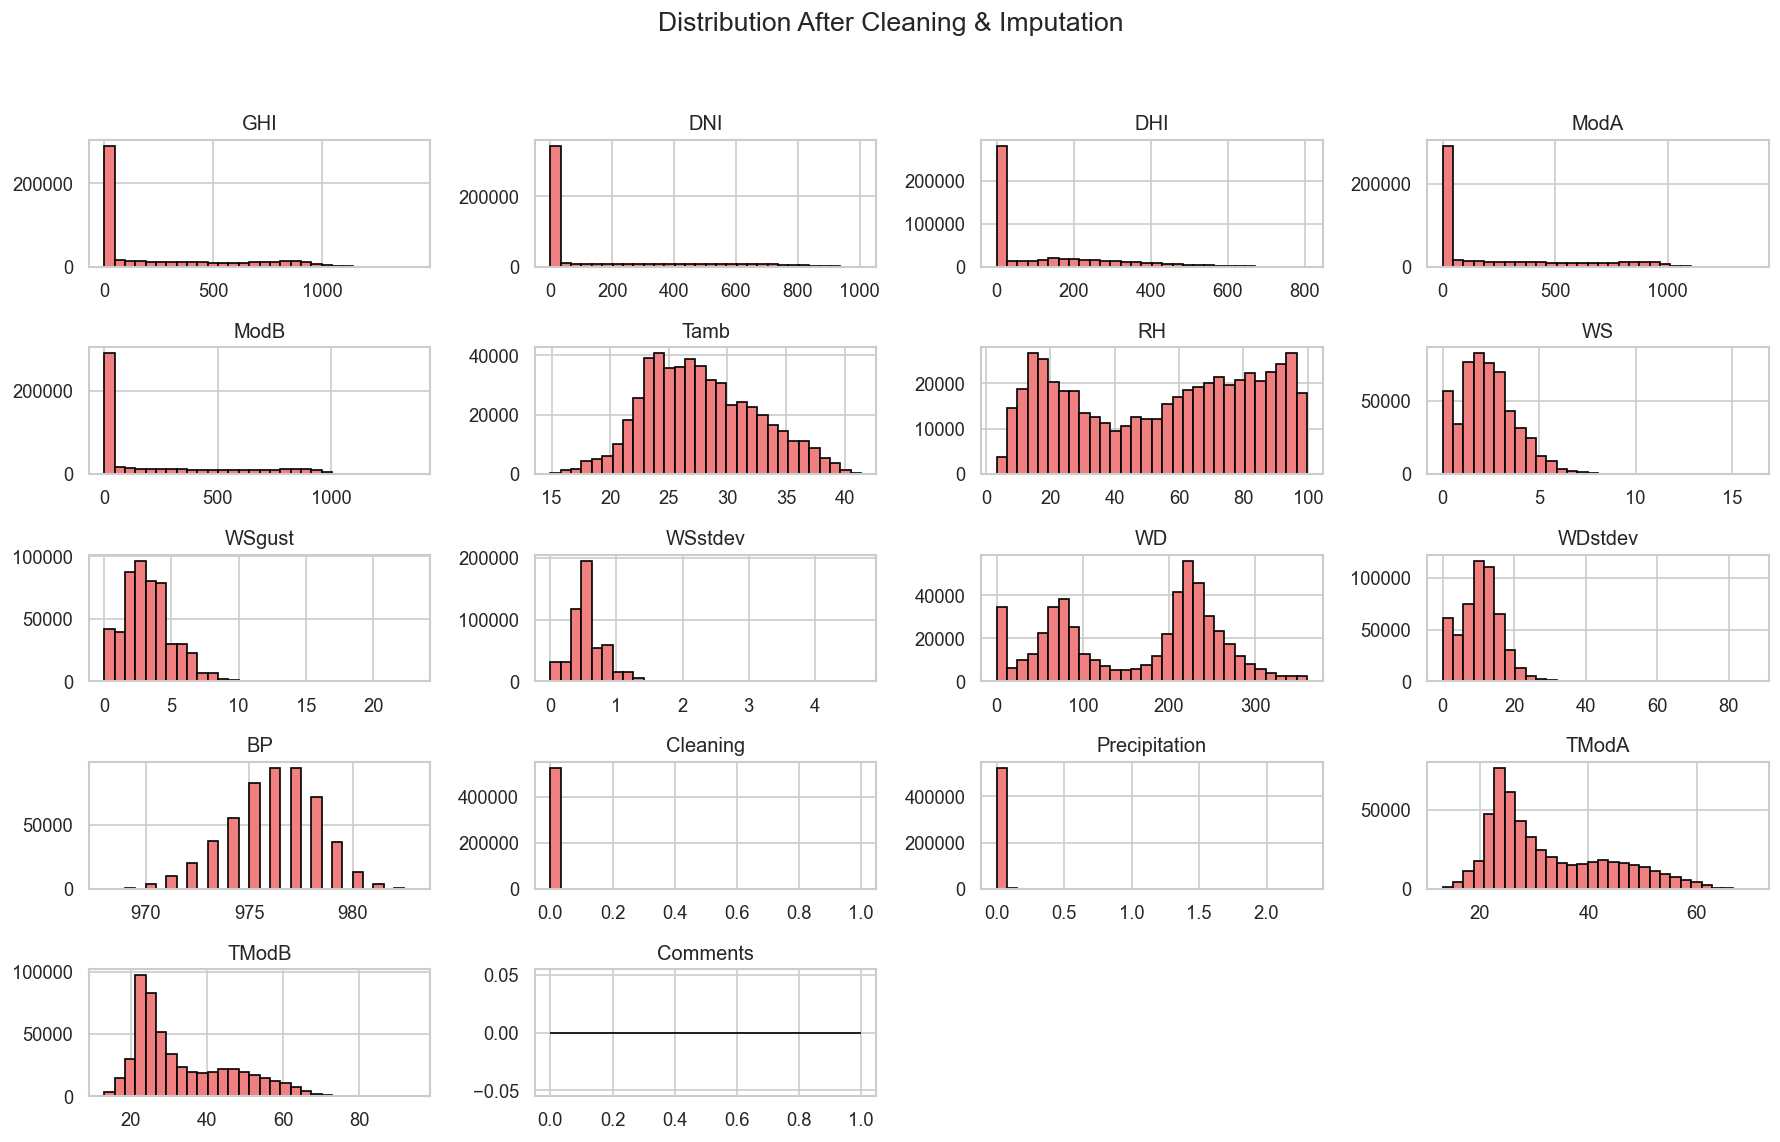

In [12]:
# distribution after cleaning and imputation
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
histograms = df_clean[numeric_cols].hist(bins=30, figsize=(15, 10), color='lightcoral', edgecolor='black')
plt.suptitle('Distribution After Cleaning & Imputation', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

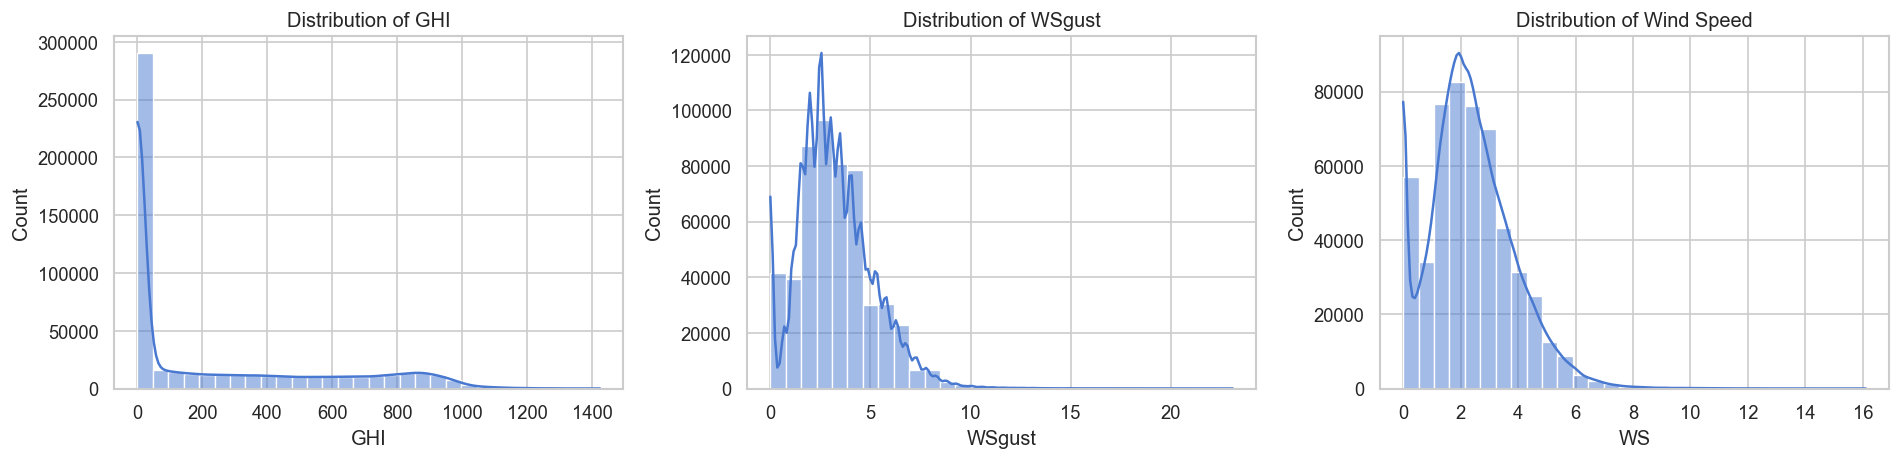

In [13]:
 # Histograms
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
sns.histplot(df_clean['GHI'], bins=30, kde=True)
plt.title('Distribution of GHI')
plt.xlabel('GHI')
plt.subplot(1, 3, 2)
sns.histplot(df_clean['WSgust'], bins=30, kde=True)
plt.title('Distribution of WSgust')
plt.xlabel('WSgust')
plt.subplot(1, 3, 3)
sns.histplot(df_clean['WS'], bins=30, kde=True)
plt.title('Distribution of Wind Speed')
plt.xlabel('WS')
plt.tight_layout()
#plt.savefig('figures/benin/histograms.png')
plt.show()

## 5. Time Series Analysis

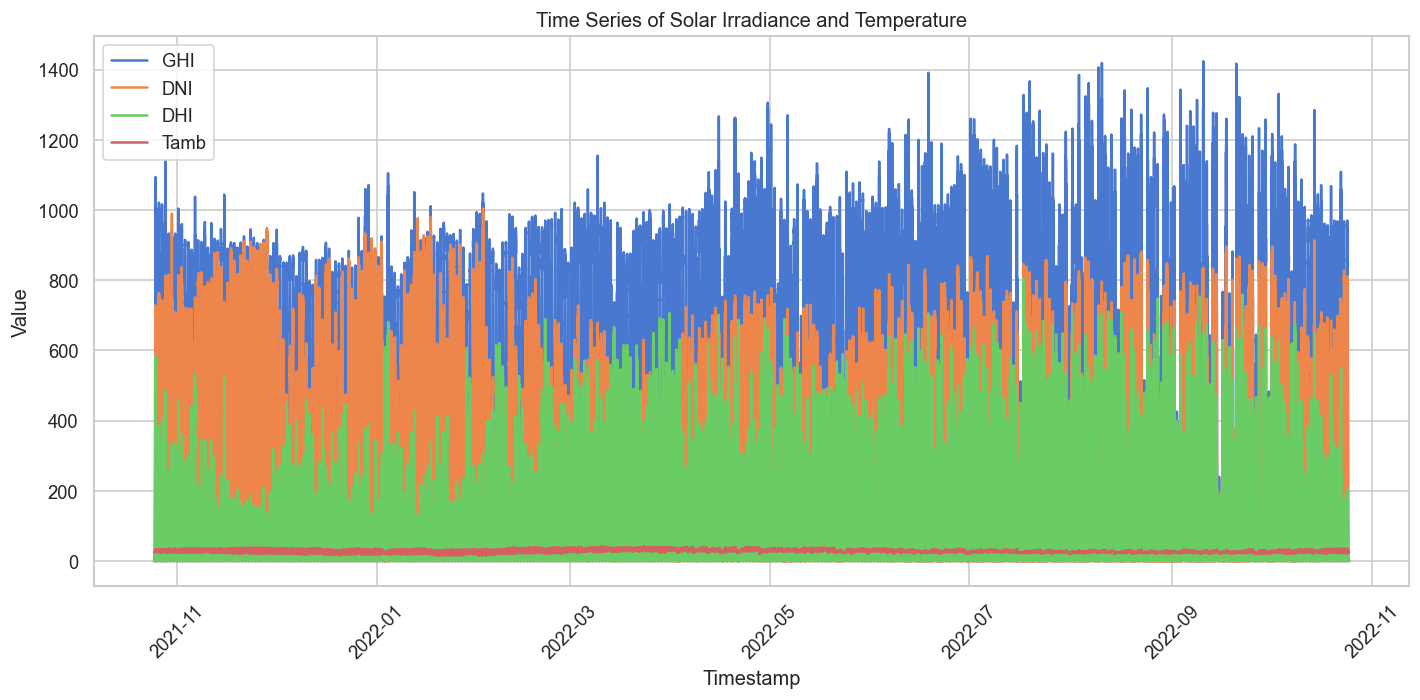

In [14]:
# 3. Time Series Analysis
plt.figure(figsize=(12, 6))
for col in ['GHI', 'DNI', 'DHI', 'Tamb']:
    plt.plot(df_clean['Timestamp'], df_clean[col], label=col)
plt.title('Time Series of Solar Irradiance and Temperature')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig('figures/benin/time_series.png')
plt.show()

# 6. Monthly Average GHI 

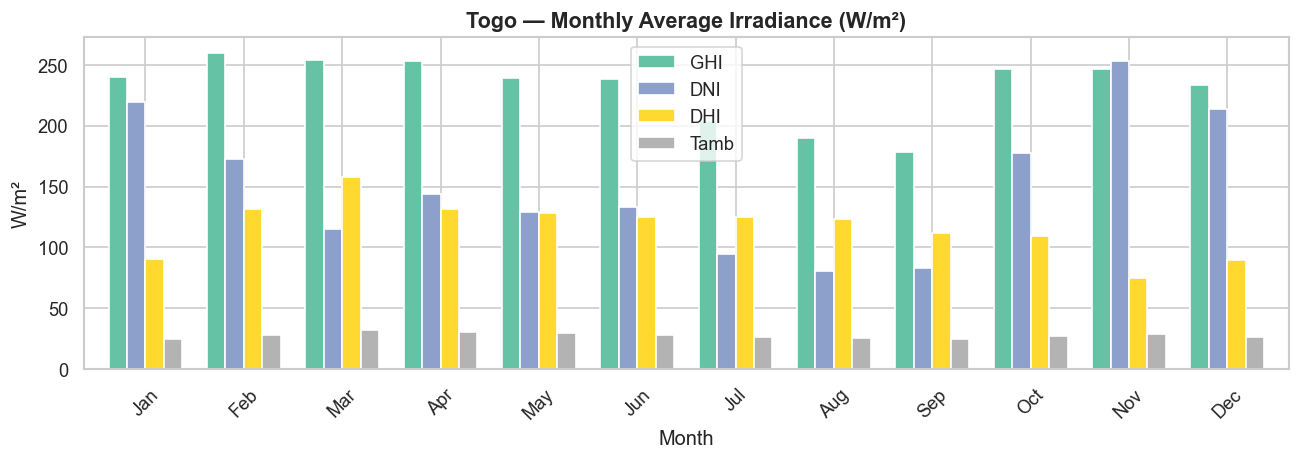


📌 Insight: Months with highest GHI indicate peak solar potential periods.


In [15]:
# ── 4.2  Monthly average GHI bar chart ───────────────────────────
df_clean['month'] = df_clean['Timestamp'].dt.month
monthly = df_clean.groupby('month')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()

monthly.plot(kind='bar', figsize=(11, 4), colormap='Set2', edgecolor='white', width=0.75)
plt.title(f'{COUNTRY.title()} — Monthly Average Irradiance (W/m²)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('W/m²')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.show()

print('\n📌 Insight: Months with highest GHI indicate peak solar potential periods.')

# 7. Daily Analysis Distribution GHI (Hour of day)

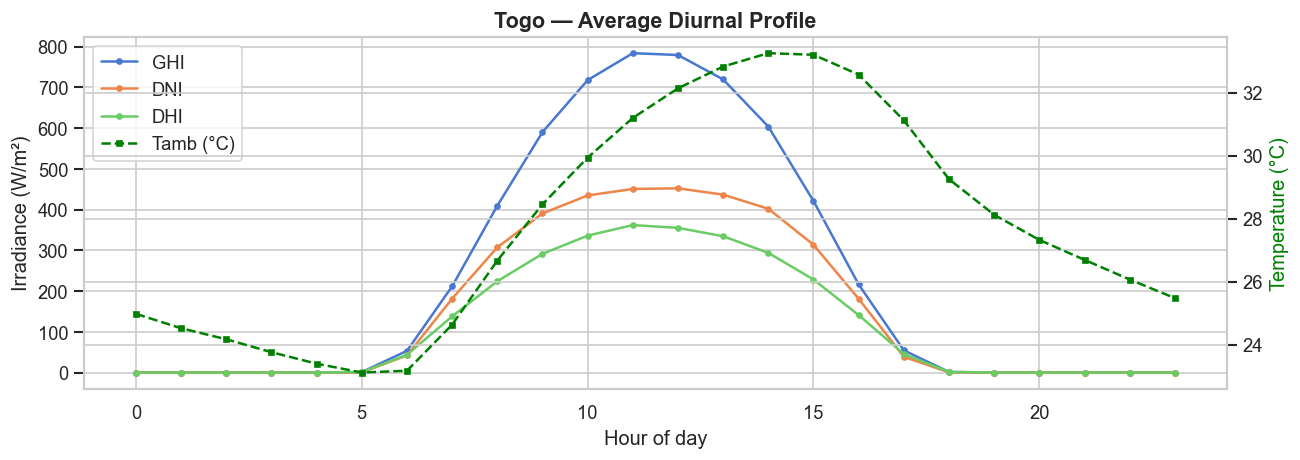


📌 Peak GHI occurs at hour 11:00 — typically solar noon.


In [16]:
# ── 4.3  Diurnal (hour-of-day) profile ───────────────────────────
df_clean['hour'] = df_clean['Timestamp'].dt.hour
hourly = df_clean.groupby('hour')[['GHI', 'DNI', 'DHI', 'Tamb']].mean()

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()

hourly[['GHI', 'DNI', 'DHI']].plot(ax=ax1, marker='o', markersize=3)
ax2.plot(hourly.index, hourly['Tamb'], color='green', linestyle='--', marker='s',
         markersize=3, label='Tamb (°C)')

ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Irradiance (W/m²)')
ax2.set_ylabel('Temperature (°C)', color='green')
ax1.set_title(f'{COUNTRY.title()} — Average Diurnal Profile', fontsize=13, fontweight='bold')
lines, labels = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(lines + l2, labels + lb2, loc='upper left')
plt.tight_layout()
plt.show()

peak_hour = hourly['GHI'].idxmax()
print(f'\n📌 Peak GHI occurs at hour {peak_hour}:00 — typically solar noon.')

## 8. Cleaning Impact Analysis

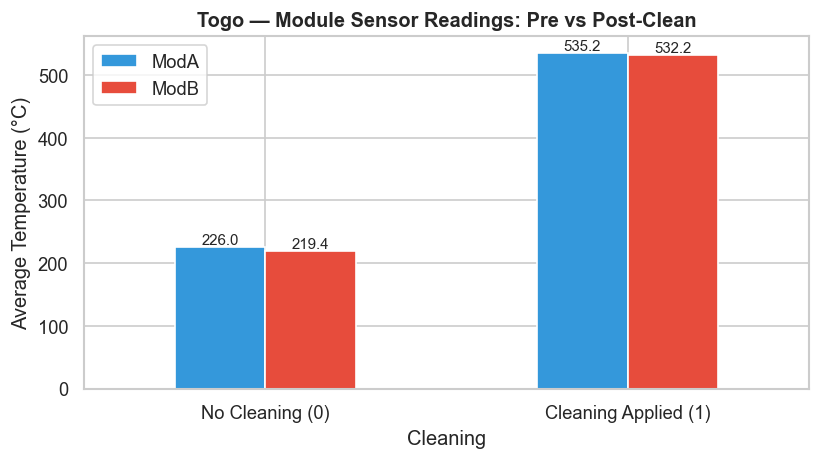


📌 Cleaning flag = 1 changes: ModA +309.21°C, ModB +312.81°C


In [17]:

if 'Cleaning' in df_clean.columns:
    clean_grp = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
    fig, ax = plt.subplots(figsize=(7, 4))
    clean_grp.plot(kind='bar', ax=ax, color=['#3498DB', '#E74C3C'], edgecolor='white', width=0.5)
    ax.set_xticklabels(['No Cleaning (0)', 'Cleaning Applied (1)'], rotation=0)
    ax.set_ylabel('Average Temperature (°C)')
    ax.set_title(f'{COUNTRY.title()} — Module Sensor Readings: Pre vs Post-Clean', fontsize=12, fontweight='bold')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    diff = clean_grp.loc[1] - clean_grp.loc[0] if 1 in clean_grp.index else None
    if diff is not None:
        print(f'\n📌 Cleaning flag = 1 changes: ModA {diff["ModA"]:+.2f}°C, ModB {diff["ModB"]:+.2f}°C')
else:
    print('Cleaning column not present in dataset.')

## 9. Correlation & Relationship Analysis

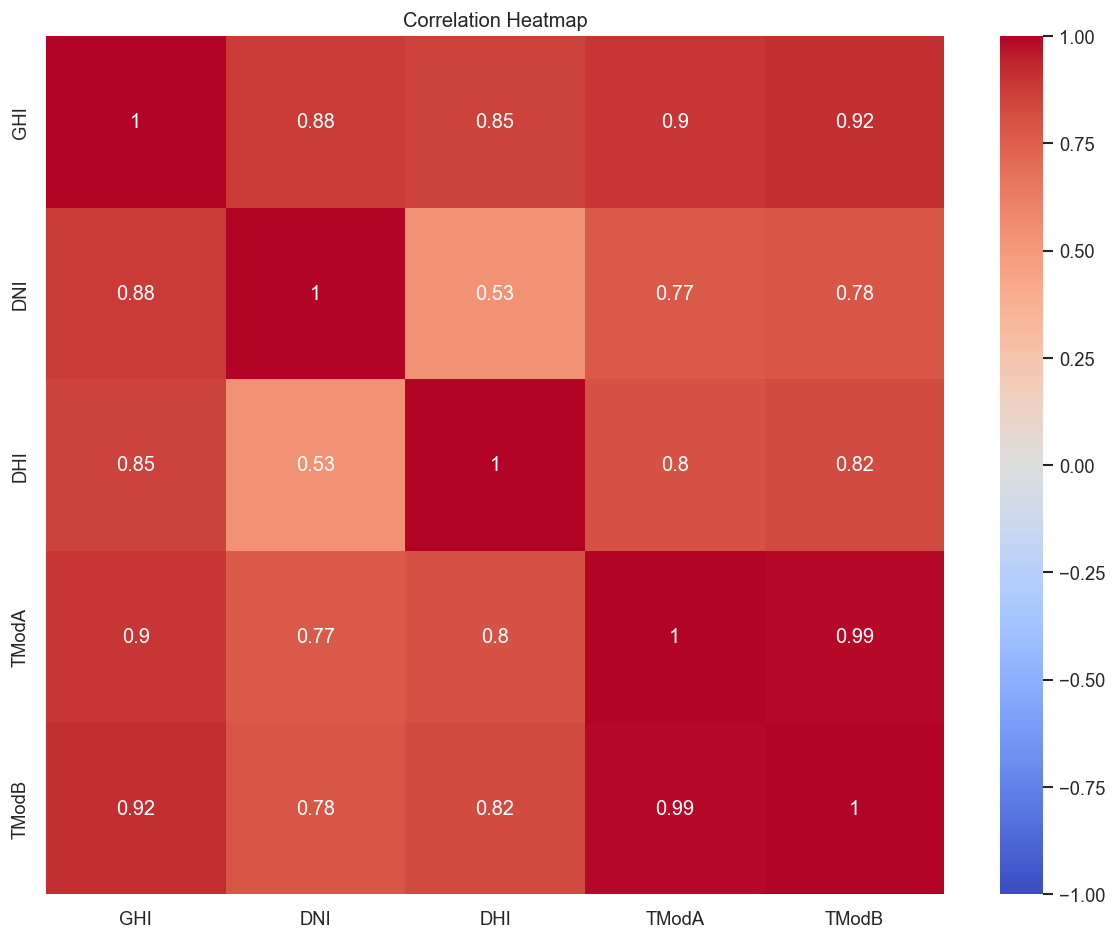

In [18]:
# 5. Correlation & Relationship Analysis
plt.figure(figsize=(10, 8))
corr = df_clean[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
#plt.savefig('figures/benin/correlation_heatmap.png')
plt.show()

# Relationship between WS,WSgust, WD VS GHI

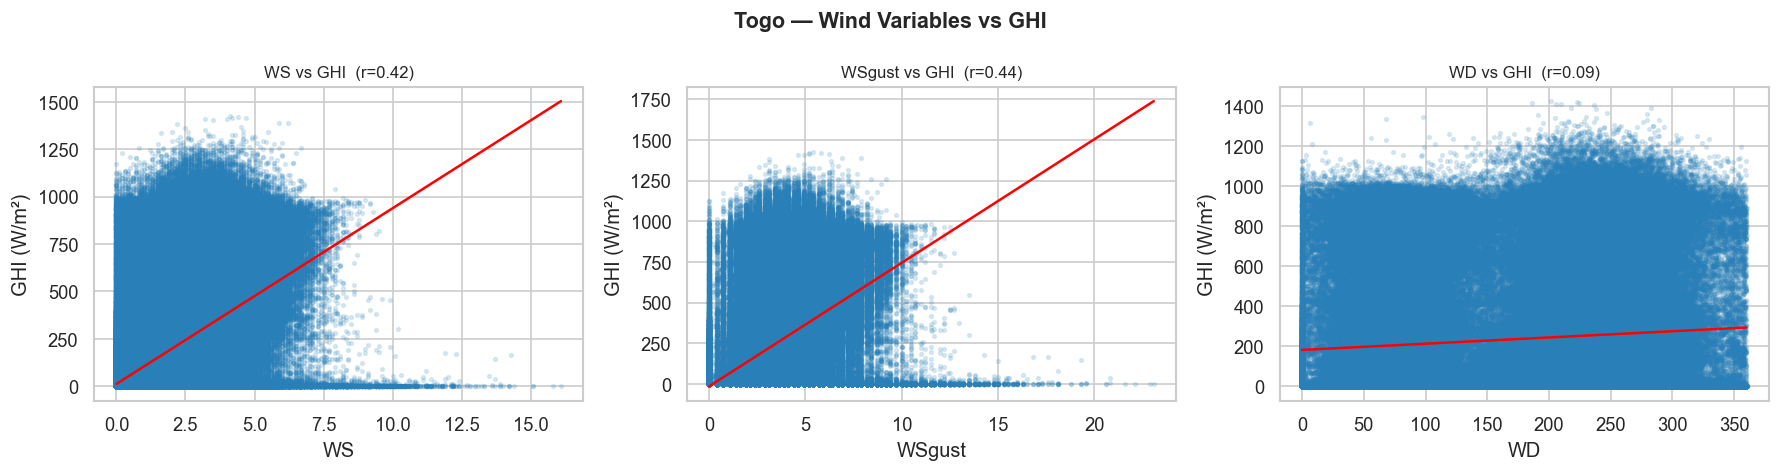

In [19]:
# ── 6.2  Scatter plots: WS, WSgust, WD vs GHI ────────────────────
scatter_pairs = [c for c in ['WS', 'WSgust', 'WD'] if c in df_clean.columns]
fig, axes = plt.subplots(1, len(scatter_pairs), figsize=(15, 4))

for ax, col in zip(axes, scatter_pairs):
    ax.scatter(df_clean[col], df_clean['GHI'], alpha=0.15, s=5, color='#2980B9')
    # add trend line
    mask_valid = df_clean[[col, 'GHI']].notna().all(axis=1)
    z = np.polyfit(df_clean.loc[mask_valid, col], df_clean.loc[mask_valid, 'GHI'], 1)
    p = np.poly1d(z)
    xs = np.linspace(df_clean[col].min(), df_clean[col].max(), 100)
    ax.plot(xs, p(xs), color='red', linewidth=1.5)
    r = df_clean[[col, 'GHI']].corr().iloc[0, 1]
    ax.set_xlabel(col)
    ax.set_ylabel('GHI (W/m²)')
    ax.set_title(f'{col} vs GHI  (r={r:.2f})', fontsize=10)

fig.suptitle(f'{COUNTRY.title()} — Wind Variables vs GHI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# RH vs Tamb and RH vs GHI

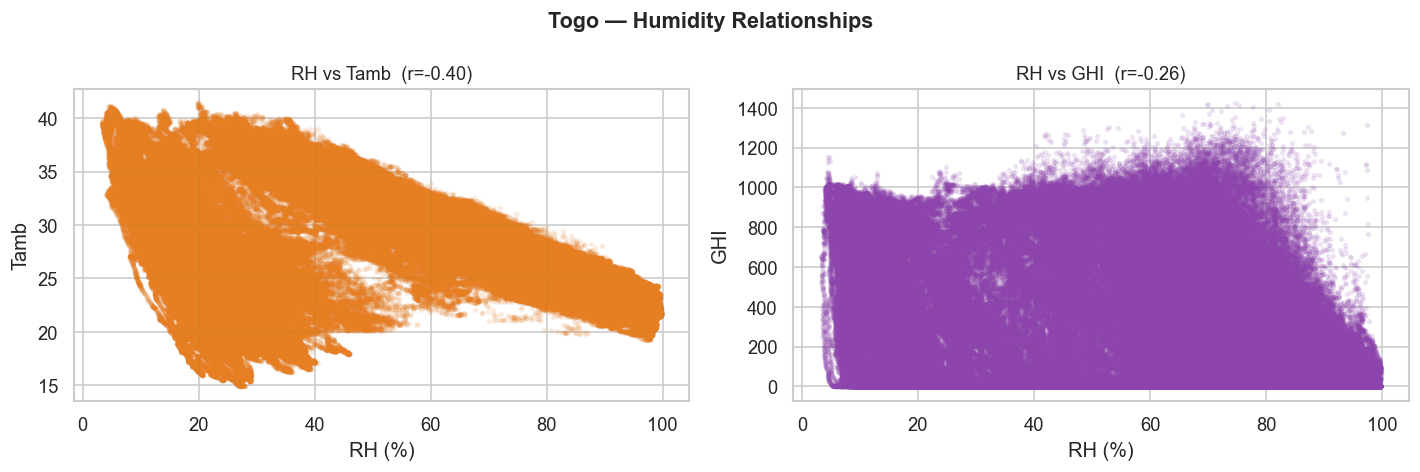


📌 RH–GHI correlation = -0.260:  High humidity tends to scatter/absorb solar radiation.


In [20]:
# ── 6.3  RH vs Tamb and RH vs GHI ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (xcol, ycol, color) in zip(axes, [('RH', 'Tamb', '#E67E22'), ('RH', 'GHI', '#8E44AD')]):
    if xcol in df_clean.columns and ycol in df_clean.columns:
        ax.scatter(df_clean[xcol], df_clean[ycol], alpha=0.1, s=5, color=color)
        r = df_clean[[xcol, ycol]].corr().iloc[0, 1]
        ax.set_xlabel(xcol + ' (%)')
        ax.set_ylabel(ycol)
        ax.set_title(f'{xcol} vs {ycol}  (r={r:.2f})', fontsize=11)

fig.suptitle(f'{COUNTRY.title()} — Humidity Relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

rh_ghi_r = df_clean[['RH','GHI']].corr().iloc[0,1]
print(f'\n📌 RH–GHI correlation = {rh_ghi_r:.3f}: ',
      'High humidity tends to scatter/absorb solar radiation.' if rh_ghi_r < -0.2 else 'Weak linear relationship — non-linear effects may dominate.')

# Wind speed Analysis

C:\Windows\Temp\ipykernel_9848\4263423237.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


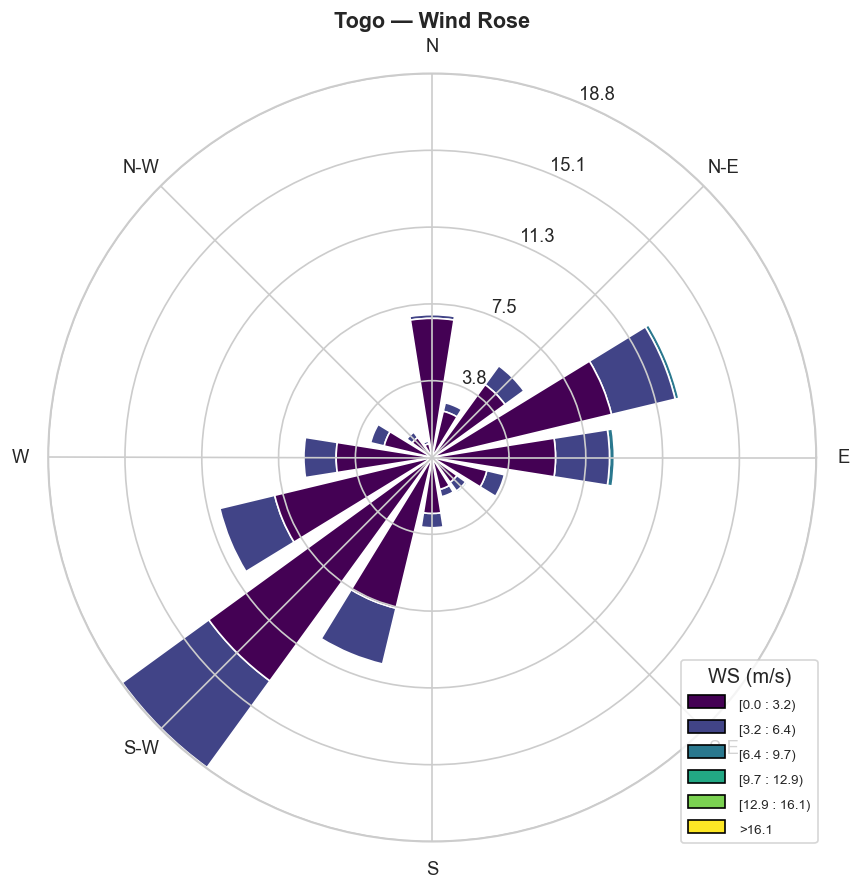

In [21]:
# ── 7.1  Wind rose (or radial bar fallback) ───────────────────────
if HAS_WINDROSE and 'WD' in df_clean.columns and 'WS' in df_clean.columns:
    fig = plt.figure(figsize=(8, 8))
    ax_wr = WindroseAxes.from_ax(fig=fig)
    ax_wr.bar(df_clean['WD'].dropna(), df_clean['WS'].dropna(),
              normed=True, opening=0.8, edgecolor='white', cmap=cm.viridis)
    ax_wr.set_legend(title='WS (m/s)', loc='lower right')
    ax_wr.set_title(f'{COUNTRY.title()} — Wind Rose', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    # Radial bar fallback using WD bins
    if 'WD' in df_clean.columns and 'WS' in df_clean.columns:
        bins = np.arange(0, 361, 22.5)
        labels = [f'{int(b)}°' for b in bins[:-1]]
        df_clean['WD_bin'] = pd.cut(df_clean['WD'], bins=bins, labels=labels, include_lowest=True)
        wind_agg = df_clean.groupby('WD_bin', observed=True)['WS'].mean()

        N = len(wind_agg)
        theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
        fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(7, 7))
        bars = ax.bar(theta, wind_agg.values, width=2*np.pi/N, alpha=0.7,
                      color=cm.viridis(np.linspace(0, 1, N)), edgecolor='white')
        ax.set_xticks(theta)
        ax.set_xticklabels(wind_agg.index, fontsize=7)
        ax.set_title(f'{COUNTRY.title()} — Radial Wind Speed by Direction', fontsize=12, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

## 10. Impact of Humidity on Temperature & Irradiance or solar radation

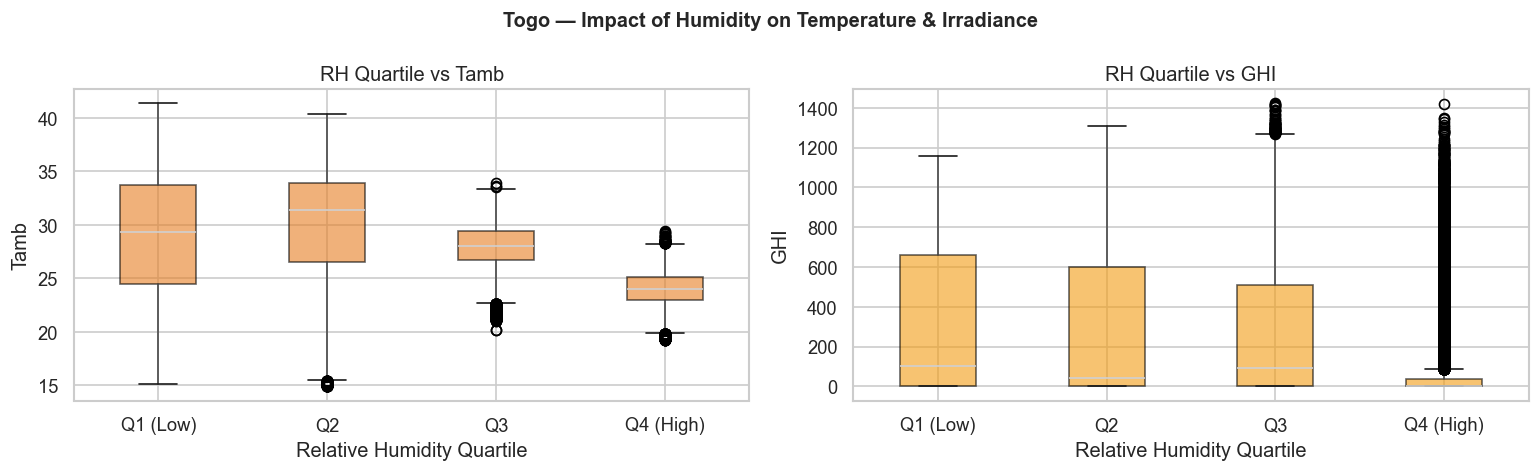


📌 Insight: Higher RH quartiles typically show lower Tamb and GHI — cloud cover associated with humid conditions reduces solar radiation.


In [22]:
# How RH influences Tamb and solar radiation ─────────────────────
# Bin RH into quartiles
if 'RH' in df_clean.columns:
    df_clean['RH_quartile'] = pd.qcut(df_clean['RH'], q=4,
                                       labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, (col, color) in zip(axes, [('Tamb', '#E67E22'), ('GHI', '#F39C12')]):
        if col in df_clean.columns:
            df_clean.boxplot(column=col, by='RH_quartile', ax=ax,
                             patch_artist=True,
                             boxprops=dict(facecolor=color, alpha=0.6))
            ax.set_xlabel('Relative Humidity Quartile')
            ax.set_ylabel(col)
            ax.set_title(f'RH Quartile vs {col}')

    fig.suptitle(f'{COUNTRY.title()} — Impact of Humidity on Temperature & Irradiance',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n📌 Insight: Higher RH quartiles typically show lower Tamb and GHI — cloud cover associated with humid conditions reduces solar radiation.')

# GHI vs Tamb (size = RH or BP)

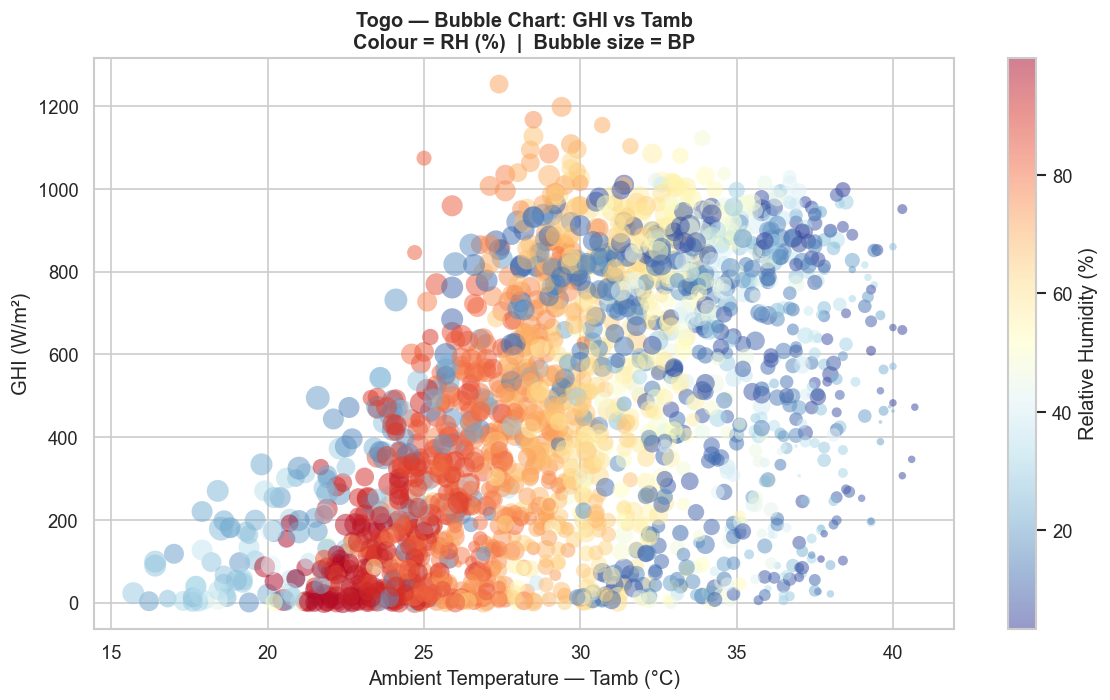


📌 Insight: Darker (high-RH) bubbles tend to cluster at lower GHI — humidity and cloud cover reduce irradiance.


In [23]:
if all(c in df_clean.columns for c in ['GHI', 'Tamb', 'RH']):
    # sample for readability
    sample = df_clean[df_clean['GHI'] > 0].sample(min(2000, len(df_clean)), random_state=42)

    bubble_size_col = 'BP' if 'BP' in sample.columns else 'RH'
    bsizes = (sample[bubble_size_col] - sample[bubble_size_col].min()) / \
             (sample[bubble_size_col].max() - sample[bubble_size_col].min()) * 200 + 5

    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(sample['Tamb'], sample['GHI'],
                    c=sample['RH'], cmap='RdYlBu_r',
                    s=bsizes, alpha=0.5, edgecolors='none')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Relative Humidity (%)')
    ax.set_xlabel('Ambient Temperature — Tamb (°C)')
    ax.set_ylabel('GHI (W/m²)')
    ax.set_title(
        f'{COUNTRY.title()} — Bubble Chart: GHI vs Tamb\n'
        f'Colour = RH (%)  |  Bubble size = {bubble_size_col}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    print('\n📌 Insight: Darker (high-RH) bubbles tend to cluster at lower GHI — humidity and cloud cover reduce irradiance.')

## 10 Summary of Key Findings

In [24]:
mean_ghi  = df_clean['GHI'].mean()
mean_dni  = df_clean['DNI'].mean()
mean_dhi  = df_clean['DHI'].mean()
peak_mo   = monthly['GHI'].idxmax()

print('=' * 55)
print(f'  BENIN EDA — Key Findings Summary')
print('=' * 55)
print(f'  Mean GHI : {mean_ghi:.1f} W/m²')
print(f'  Mean DNI : {mean_dni:.1f} W/m²')
print(f'  Mean DHI : {mean_dhi:.1f} W/m²')
print(f'  Peak solar month : {peak_mo} (highest avg GHI)')
print(f'  Peak hour        : {peak_hour}:00')
print(f'  Outliers flagged : {df["outlier_flag"].sum()} rows ({df["outlier_flag"].mean()*100:.1f}%)')
print(f'  RH–GHI correlation: {rh_ghi_r:.3f}')
print('=' * 55)
print('✔  Cleaned CSV saved to data/benin_clean.csv')

  BENIN EDA — Key Findings Summary
  Mean GHI : 231.7 W/m²
  Mean DNI : 151.3 W/m²
  Mean DHI : 116.4 W/m²
  Peak solar month : 2 (highest avg GHI)
  Peak hour        : 11:00
  Outliers flagged : 9257 rows (1.8%)
  RH–GHI correlation: -0.260
✔  Cleaned CSV saved to data/benin_clean.csv
